In [1]:
import numpy as np
import tifffile
import torch
import matplotlib.pyplot as plt

from pathlib import Path
from skimage.measure import regionprops
from skimage.color import label2rgb
from segment_anything import sam_model_registry, SamPredictor

In [2]:
RAW_DIR = Path("/QRISdata/Q6080/Q6080/IndividualLabFolders/AG/DRGAnushka/resonant")
CELLPOSE_MASK_DIR = Path.home() / "cellpose_masks_resonant"
CKPT_PATH = Path.home() / "sam_checkpoints" / "sam_vit_b_01ec64.pth"

raw_files = sorted(
    [f for f in RAW_DIR.glob("*.tif") if not f.name.startswith(".")] +
    [f for f in RAW_DIR.glob("*.tiff") if not f.name.startswith(".")]
)

raw_fp = raw_files[0]
mask_fp = CELLPOSE_MASK_DIR / f"{raw_fp.stem}_masks.tif"

print("RAW:", raw_fp)
print("MASK:", mask_fp)

# read only first frame from resonant TIFF
with tifffile.TiffFile(raw_fp) as tif:
    frame0 = tif.pages[0].asarray()

cp_masks = tifffile.imread(mask_fp)

print("Frame shape:", frame0.shape, frame0.dtype)
print("Mask shape:", cp_masks.shape, cp_masks.dtype, "labels:", int(cp_masks.max()))

RAW: /QRISdata/Q6080/Q6080/IndividualLabFolders/AG/DRGAnushka/resonant/614399S2D20250113.tif
MASK: /home/s4906996/cellpose_masks_resonant/614399S2D20250113_masks.tif
Frame shape: (512, 512) uint16
Mask shape: (512, 512) uint16 labels: 21


In [3]:
im2d = frame0.astype(np.float32)
im2d = (im2d - im2d.min()) / (im2d.max() - im2d.min() + 1e-8)

rgb = np.repeat((im2d * 255).astype(np.uint8)[..., None], 3, axis=-1)

print("RGB ready:", rgb.shape, rgb.dtype)

RGB ready: (512, 512, 3) uint8


In [4]:
sam_cpu = sam_model_registry["vit_b"](checkpoint=str(CKPT_PATH))
sam_cpu.to(device="cpu")

predictor_cpu = SamPredictor(sam_cpu)

with torch.inference_mode():
    predictor_cpu.set_image(rgb)

print("CPU SAM embedding done")

CPU SAM embedding done


In [5]:
def refine_all_masks_with_sam(cp_masks, predictor, box_expand=6, min_area=30):
    refined_masks = np.zeros_like(cp_masks, dtype=np.uint16)

    props = regionprops(cp_masks)
    props = [roi for roi in props if roi.area >= min_area]

    print("Total ROIs to refine:", len(props))

    H, W = cp_masks.shape
    new_id = 1

    for i, roi in enumerate(props, start=1):
        lab = roi.label
        cp_roi = (cp_masks == lab)

        minr, minc, maxr, maxc = roi.bbox
        minr = max(0, minr - box_expand)
        minc = max(0, minc - box_expand)
        maxr = min(H, maxr + box_expand)
        maxc = min(W, maxc + box_expand)

        box = np.array([minc, minr, maxc, maxr], dtype=np.float32)

        cy, cx = roi.centroid
        point_coords = np.array([[cx, cy]], dtype=np.float32)
        point_labels = np.array([1], dtype=np.int32)

        with torch.inference_mode():
            masks, scores, _ = predictor.predict(
                box=box[None, :],
                point_coords=point_coords,
                point_labels=point_labels,
                multimask_output=True
            )

        best_i = int(np.argmax(scores))
        sam_roi = masks[best_i]

        # optional fallback if SAM drifts too much
        overlap = (sam_roi & cp_roi).sum() / (cp_roi.sum() + 1e-8)
        if overlap < 0.15:
            sam_roi = cp_roi

        refined_masks[sam_roi] = new_id

        print(f"Processed ROI {i}/{len(props)} | label={lab} | score={scores[best_i]:.4f}")
        new_id += 1

    return refined_masks

In [6]:
sam_masks_full = refine_all_masks_with_sam(cp_masks, predictor_cpu, box_expand=6, min_area=30)

print("Original Cellpose masks:", int(cp_masks.max()))
print("SAM refined masks:", int(sam_masks_full.max()))

Total ROIs to refine: 21
Processed ROI 1/21 | label=1 | score=0.9575
Processed ROI 2/21 | label=2 | score=0.9815
Processed ROI 3/21 | label=3 | score=0.9896
Processed ROI 4/21 | label=4 | score=0.9633
Processed ROI 5/21 | label=5 | score=0.9194
Processed ROI 6/21 | label=6 | score=0.9357
Processed ROI 7/21 | label=7 | score=0.9598
Processed ROI 8/21 | label=8 | score=0.9624
Processed ROI 9/21 | label=9 | score=0.9378
Processed ROI 10/21 | label=10 | score=0.9409
Processed ROI 11/21 | label=11 | score=0.9281
Processed ROI 12/21 | label=12 | score=0.9360
Processed ROI 13/21 | label=13 | score=0.9539
Processed ROI 14/21 | label=14 | score=0.9401
Processed ROI 15/21 | label=15 | score=0.9438
Processed ROI 16/21 | label=16 | score=0.9276
Processed ROI 17/21 | label=17 | score=0.9284
Processed ROI 18/21 | label=18 | score=0.9523
Processed ROI 19/21 | label=19 | score=0.8951
Processed ROI 20/21 | label=20 | score=0.9124
Processed ROI 21/21 | label=21 | score=0.9497
Original Cellpose masks: 21

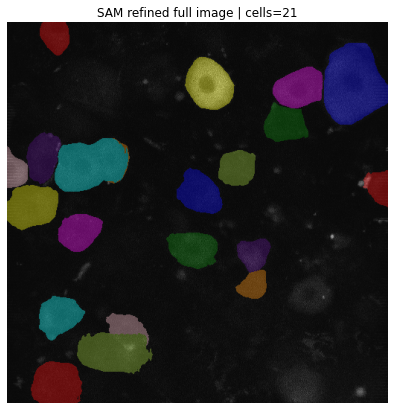

In [7]:
overlay_sam = label2rgb(sam_masks_full, image=im2d, bg_label=0, alpha=0.35)

plt.figure(figsize=(7,7))
plt.imshow(overlay_sam)
plt.title(f"SAM refined full image | cells={int(sam_masks_full.max())}")
plt.axis("off")
plt.show()

In [8]:
OUT_DIR = Path.home() / "cellpose_sam_results"
OUT_DIR.mkdir(parents=True, exist_ok=True)

mask_out = OUT_DIR / f"{raw_fp.stem}_sam_masks.tif"
overlay_out = OUT_DIR / f"{raw_fp.stem}_sam_overlay.png"

tifffile.imwrite(mask_out, sam_masks_full.astype(np.uint16))

plt.figure(figsize=(7,7))
plt.imshow(overlay_sam)
plt.title(f"SAM refined | {raw_fp.name}")
plt.axis("off")
plt.tight_layout()
plt.savefig(overlay_out, dpi=200, bbox_inches="tight")
plt.close()

print("Saved SAM mask:", mask_out)
print("Saved SAM overlay:", overlay_out)

Saved SAM mask: /home/s4906996/cellpose_sam_results/614399S2D20250113_sam_masks.tif
Saved SAM overlay: /home/s4906996/cellpose_sam_results/614399S2D20250113_sam_overlay.png


In [9]:
import csv

OUT_DIR = Path.home() / "cellpose_sam_results"
OUT_DIR.mkdir(parents=True, exist_ok=True)

results = []
failed = []

for raw_fp in raw_files:
    try:
        print(f"\nProcessing: {raw_fp.name}")

        mask_fp = CELLPOSE_MASK_DIR / f"{raw_fp.stem}_masks.tif"
        if not mask_fp.exists():
            raise FileNotFoundError(f"Missing Cellpose mask: {mask_fp.name}")

        # read only first frame from resonant TIFF
        with tifffile.TiffFile(raw_fp) as tif:
            frame0 = tif.pages[0].asarray()

        cp_masks = tifffile.imread(mask_fp)

        # prepare image
        im2d = frame0.astype(np.float32)
        im2d = (im2d - im2d.min()) / (im2d.max() - im2d.min() + 1e-8)
        rgb = np.repeat((im2d * 255).astype(np.uint8)[..., None], 3, axis=-1)

        # load SAM image embedding for this image
        with torch.inference_mode():
            predictor_cpu.set_image(rgb)

        # refine all masks in this image
        sam_masks_full = refine_all_masks_with_sam(
            cp_masks,
            predictor_cpu,
            box_expand=6,
            min_area=30
        )

        sam_count = int(sam_masks_full.max())

        # overlay
        overlay_sam = label2rgb(sam_masks_full, image=im2d, bg_label=0, alpha=0.35)

        # save outputs
        mask_out = OUT_DIR / f"{raw_fp.stem}_sam_masks.tif"
        overlay_out = OUT_DIR / f"{raw_fp.stem}_sam_overlay.png"

        tifffile.imwrite(mask_out, sam_masks_full.astype(np.uint16))

        plt.figure(figsize=(7,7))
        plt.imshow(overlay_sam)
        plt.title(f"SAM refined | {raw_fp.name} | cells={sam_count}")
        plt.axis("off")
        plt.tight_layout()
        plt.savefig(overlay_out, dpi=200, bbox_inches="tight")
        plt.close()

        results.append([raw_fp.name, sam_count])
        print(f"Saved: {mask_out.name}, {overlay_out.name}, cells={sam_count}")

    except Exception as e:
        failed.append([raw_fp.name, str(e)])
        print(f"Failed: {raw_fp.name} | {e}")


Processing: 614399S2D20250113.tif
Total ROIs to refine: 21
Processed ROI 1/21 | label=1 | score=0.9575
Processed ROI 2/21 | label=2 | score=0.9815
Processed ROI 3/21 | label=3 | score=0.9896
Processed ROI 4/21 | label=4 | score=0.9633
Processed ROI 5/21 | label=5 | score=0.9194
Processed ROI 6/21 | label=6 | score=0.9357
Processed ROI 7/21 | label=7 | score=0.9598
Processed ROI 8/21 | label=8 | score=0.9624
Processed ROI 9/21 | label=9 | score=0.9378
Processed ROI 10/21 | label=10 | score=0.9409
Processed ROI 11/21 | label=11 | score=0.9281
Processed ROI 12/21 | label=12 | score=0.9360
Processed ROI 13/21 | label=13 | score=0.9539
Processed ROI 14/21 | label=14 | score=0.9401
Processed ROI 15/21 | label=15 | score=0.9438
Processed ROI 16/21 | label=16 | score=0.9276
Processed ROI 17/21 | label=17 | score=0.9284
Processed ROI 18/21 | label=18 | score=0.9523
Processed ROI 19/21 | label=19 | score=0.8951
Processed ROI 20/21 | label=20 | score=0.9124
Processed ROI 21/21 | label=21 | score

In [10]:
csv_out = OUT_DIR / "sam_trace_counts.csv"
failed_out = OUT_DIR / "sam_failed_files.csv"

with open(csv_out, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["filename", "sam_cells_detected"])
    writer.writerows(results)

with open(failed_out, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["filename", "error"])
    writer.writerows(failed)

print("Saved CSV:", csv_out)
print("Saved failed log:", failed_out)
print("Done.")

Saved CSV: /home/s4906996/cellpose_sam_results/sam_trace_counts.csv
Saved failed log: /home/s4906996/cellpose_sam_results/sam_failed_files.csv
Done.
